<a href="https://colab.research.google.com/github/Shirsh21/customer-spend-prediction/blob/main/customer_spend_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)

# 1. Generate Unique Customers
n_customers = 15000
customer_ids = np.arange(1, n_customers + 1)

ages = np.random.randint(18, 70, size=n_customers)
genders = np.random.choice(['Male', 'Female', 'Other'], size=n_customers, p=[0.48, 0.48, 0.04])
incomes = np.random.normal(65000, 25000, size=n_customers).clip(25000, 250000)
educations = np.random.choice(['High School', 'Bachelors', 'Masters', 'PhD'], size=n_customers, p=[0.3, 0.4, 0.2, 0.1])
regions = np.random.choice(['North', 'South', 'East', 'West'], size=n_customers)
loyalty_statuses = np.random.choice(['Regular', 'Silver', 'Gold'], size=n_customers, p=[0.6, 0.25, 0.15])
purchase_freqs = np.random.choice(['Rare', 'Occasional', 'Frequent'], size=n_customers, p=[0.3, 0.5, 0.2])

# Generate dummy phone numbers
phnos = ['+1-555-' + str(np.random.randint(1000, 9999)) for _ in range(n_customers)]

# Determine number of transactions per customer based on their frequency tier
tx_counts = []
for freq in purchase_freqs:
    if freq == 'Frequent':
        tx_counts.append(np.random.randint(30, 60))
    elif freq == 'Occasional':
        tx_counts.append(np.random.randint(10, 29))
    else: # Rare
        tx_counts.append(np.random.randint(2, 9))

tx_counts = np.array(tx_counts)
total_transactions = tx_counts.sum()

# 2. Expand Customer Data to Transaction Level
customer_ids_repeated = np.repeat(customer_ids, tx_counts)
ages_repeated = np.repeat(ages, tx_counts)
phnos_repeated = np.repeat(phnos, tx_counts)
genders_repeated = np.repeat(genders, tx_counts)
incomes_repeated = np.repeat(incomes, tx_counts)
educations_repeated = np.repeat(educations, tx_counts)
regions_repeated = np.repeat(regions, tx_counts)
loyalty_statuses_repeated = np.repeat(loyalty_statuses, tx_counts)
purchase_freqs_repeated = np.repeat(purchase_freqs, tx_counts)

# 3. Generate Transaction-Specific Data (Over a 12-month period: Jan 1, 2025 - Dec 31, 2025)
start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 12, 31)
date_range_days = (end_date - start_date).days

# Randomize dates for each transaction
random_days = np.random.randint(0, date_range_days, size=total_transactions)
purchase_dates = [start_date + timedelta(days=int(day)) for day in random_days]

product_categories = np.random.choice(['Clothing', 'Electronics', 'Food', 'Healthcare'], size=total_transactions, p=[0.3, 0.2, 0.4, 0.1])
promotional_usages = np.random.choice([0, 1], size=total_transactions, p=[0.7, 0.3])

# Calculate purchase amount based on category and income
base_amounts = {
    'Food': 50,
    'Clothing': 120,
    'Healthcare': 80,
    'Electronics': 400
}

purchase_amts = []
for i in range(total_transactions):
    cat = product_categories[i]
    income_multiplier = incomes_repeated[i] / 65000
    promo_discount = 0.8 if promotional_usages[i] == 1 else 1.0

    # Add noise
    noise = np.random.normal(1.0, 0.2)

    amt = base_amounts[cat] * income_multiplier * promo_discount * noise
    purchase_amts.append(round(max(5.0, amt), 2)) # Minimum $5 spend

# 4. Compile into DataFrame
df = pd.DataFrame({
    'id': customer_ids_repeated,
    'age': ages_repeated,
    'phno': phnos_repeated,
    'gender': genders_repeated,
    'income': np.round(incomes_repeated, 2),
    'education': educations_repeated,
    'region': regions_repeated,
    'loyalty_status': loyalty_statuses_repeated,
    'purchase_freq': purchase_freqs_repeated,
    'purchase_date': purchase_dates,
    'product_category': product_categories,
    'promotional_usage': promotional_usages,
    'purchase_amt': purchase_amts
})

# Sort by customer ID and then by date to simulate a real chronological database
df = df.sort_values(by=['id', 'purchase_date']).reset_index(drop=True)

# Export to CSV
file_name = 'transactional_customer_data.csv'
df.to_csv(file_name, index=False)

print(f"Dataset generated! Total Rows: {len(df)}")

Dataset generated! Total Rows: 296275


In [ ]:
df.head()

,id,age,phno,gender,income,education,region,loyalty_status,purchase_freq,purchase_date,product_category,promotional_usage,purchase_amt
0,1,56,+1-555-2491,Other,68627.79,High School,East,Regular,Rare,2025-01-01,Food,0,57.38
1,1,56,+1-555-2491,Other,68627.79,High School,East,Regular,Rare,2025-05-19,Clothing,1,66.69
2,1,56,+1-555-2491,Other,68627.79,High School,East,Regular,Rare,2025-08-09,Clothing,0,120.67
3,1,56,+1-555-2491,Other,68627.79,High School,East,Regular,Rare,2025-08-12,Clothing,1,65.49
4,1,56,+1-555-2491,Other,68627.79,High School,East,Regular,Rare,2025-10-17,Clothing,0,101.96


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)

# 1. Generate Unique Customers
n_customers = 15000
customer_ids = np.arange(1, n_customers + 1)

ages = np.random.randint(18, 70, size=n_customers)
genders = np.random.choice(['Male', 'Female', 'Other'], size=n_customers, p=[0.48, 0.48, 0.04])
incomes = np.random.normal(65000, 25000, size=n_customers).clip(25000, 250000)
educations = np.random.choice(['High School', 'Bachelors', 'Masters', 'PhD'], size=n_customers, p=[0.3, 0.4, 0.2, 0.1])
regions = np.random.choice(['North', 'South', 'East', 'West'], size=n_customers)
loyalty_statuses = np.random.choice(['Regular', 'Silver', 'Gold'], size=n_customers, p=[0.6, 0.25, 0.15])
purchase_freqs = np.random.choice(['Rare', 'Occasional', 'Frequent'], size=n_customers, p=[0.3, 0.5, 0.2])

# OPTION 1: Health Status (Correlated with Age)
health_statuses = []
for age in ages:
    if age < 35:
        health_statuses.append(np.random.choice(['Excellent', 'Good', 'Fair', 'Poor'], p=[0.6, 0.3, 0.08, 0.02]))
    elif age < 55:
        health_statuses.append(np.random.choice(['Excellent', 'Good', 'Fair', 'Poor'], p=[0.2, 0.5, 0.2, 0.1]))
    else:
        health_statuses.append(np.random.choice(['Excellent', 'Good', 'Fair', 'Poor'], p=[0.05, 0.3, 0.4, 0.25]))
health_statuses = np.array(health_statuses)

# OPTION 3: Tech Ecosystem Lock (Binary 0/1 - e.g., heavily invested in Apple/Samsung ecosystem)
tech_locks = np.random.choice([0, 1], size=n_customers, p=[0.6, 0.4])

# OPTION 4: Financial Discipline Index (1-100 scale)
# Higher income and higher education loosely correlate with slightly better financial discipline
fin_discipline = np.random.normal(50, 15, size=n_customers) + (incomes / 20000)
fin_discipline = np.clip(fin_discipline, 1, 100).astype(int)

# Determine number of transactions per customer based on their frequency tier
tx_counts = []
for freq in purchase_freqs:
    if freq == 'Frequent':
        tx_counts.append(np.random.randint(30, 60))
    elif freq == 'Occasional':
        tx_counts.append(np.random.randint(10, 29))
    else: # Rare
        tx_counts.append(np.random.randint(2, 9))
tx_counts = np.array(tx_counts)
total_transactions = tx_counts.sum()

# 2. Expand Customer Data to Transaction Level
customer_ids_repeated = np.repeat(customer_ids, tx_counts)
ages_repeated = np.repeat(ages, tx_counts)
genders_repeated = np.repeat(genders, tx_counts)
incomes_repeated = np.repeat(incomes, tx_counts)
educations_repeated = np.repeat(educations, tx_counts)
regions_repeated = np.repeat(regions, tx_counts)
loyalty_statuses_repeated = np.repeat(loyalty_statuses, tx_counts)
health_statuses_repeated = np.repeat(health_statuses, tx_counts)
tech_locks_repeated = np.repeat(tech_locks, tx_counts)
fin_discipline_repeated = np.repeat(fin_discipline, tx_counts)

# 3. Generate Transaction-Specific Data (Over a 12-month period)
start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 12, 31)
date_range_days = (end_date - start_date).days

random_days = np.random.randint(0, date_range_days, size=total_transactions)
purchase_dates = [start_date + timedelta(days=int(day)) for day in random_days]

# OPTION 2: Categories and Sub-Categories Allocation
product_categories = []
sub_categories = []
promotional_usages = []
purchase_amts = []

for i in range(total_transactions):
    # Determine base category
    cat = np.random.choice(['Food', 'Electronics', 'Clothing', 'Healthcare'], p=[0.4, 0.15, 0.25, 0.2])
    sub_cat = ""
    base_amt = 0

    # Financial discipline impacts promo usage
    prob_promo = 0.8 if fin_discipline_repeated[i] > 70 else 0.2
    promo = np.random.choice([1, 0], p=[prob_promo, 1-prob_promo])

    # Category and Sub-category Logic
    if cat == 'Food':
        # High financial discipline -> more standard groceries, less outside dining
        # Excellent health -> more meal prep
        if health_statuses_repeated[i] == 'Excellent':
            sub_cat = np.random.choice(['Meal_Prep_Groceries', 'Outside_Dining', 'Standard_Groceries'], p=[0.6, 0.1, 0.3])
        elif fin_discipline_repeated[i] > 70:
            sub_cat = np.random.choice(['Standard_Groceries', 'Outside_Dining'], p=[0.85, 0.15])
        else:
            sub_cat = np.random.choice(['Outside_Dining', 'Standard_Groceries'], p=[0.6, 0.4])

        base_amt = 40 if sub_cat == 'Outside_Dining' else (120 if sub_cat == 'Standard_Groceries' else 90)

    elif cat == 'Electronics':
        # Tech lock increases impulse gadget buys (accessories) and flagship upgrades
        if tech_locks_repeated[i] == 1:
            sub_cat = np.random.choice(['Flagship_Upgrade', 'Impulse_Gadget', 'Replacement'], p=[0.2, 0.7, 0.1])
        else:
            sub_cat = np.random.choice(['Flagship_Upgrade', 'Impulse_Gadget', 'Replacement'], p=[0.05, 0.2, 0.75])

        base_amt = 1000 if sub_cat == 'Flagship_Upgrade' else (150 if sub_cat == 'Impulse_Gadget' else 50)

    elif cat == 'Clothing':
        # High financial discipline avoids trend impulse
        if fin_discipline_repeated[i] > 70:
            sub_cat = 'Seasonal_Wardrobe'
        else:
            sub_cat = np.random.choice(['Seasonal_Wardrobe', 'Trend_Impulse'], p=[0.4, 0.6])

        base_amt = 200 if sub_cat == 'Seasonal_Wardrobe' else 60

    elif cat == 'Healthcare':
        # Poor health leads to major medical, excellent health leads to supplements/preventative
        if health_statuses_repeated[i] in ['Poor', 'Fair']:
            sub_cat = np.random.choice(['Major_Medical', 'Routine_Checkup'], p=[0.7, 0.3])
        else:
            sub_cat = np.random.choice(['Supplements_Fitness', 'Routine_Checkup'], p=[0.8, 0.2])

        base_amt = 500 if sub_cat == 'Major_Medical' else (100 if sub_cat == 'Routine_Checkup' else 60)

    # Calculate final amount
    income_multiplier = max(0.5, incomes_repeated[i] / 65000)
    promo_discount = 0.75 if promo == 1 else 1.0
    noise = np.random.normal(1.0, 0.15)

    final_amt = round(max(5.0, base_amt * income_multiplier * promo_discount * noise), 2)

    product_categories.append(cat)
    sub_categories.append(sub_cat)
    promotional_usages.append(promo)
    purchase_amts.append(final_amt)

# 4. Compile into DataFrame
df = pd.DataFrame({
    'Customer_ID': customer_ids_repeated,
    'Age': ages_repeated,
    'Gender': genders_repeated,
    'Annual_Income_USD': np.round(incomes_repeated, 2),
    'Education_Level': educations_repeated,
    'Region': regions_repeated,
    'Loyalty_Status': loyalty_statuses_repeated,
    'Health_Status': health_statuses_repeated,               # Option 1
    'Tech_Ecosystem_Lock': tech_locks_repeated,              # Option 3
    'Financial_Discipline_Index': fin_discipline_repeated,   # Option 4
    'Purchase_Date': purchase_dates,
    'Product_Category': product_categories,
    'Sub_Category': sub_categories,                          # Option 2
    'Promotional_Usage': promotional_usages,
    'Purchase_Amt_USD': purchase_amts
})

# Sort by customer ID and then chronologically
df = df.sort_values(by=['Customer_ID', 'Purchase_Date']).reset_index(drop=True)

# Export to CSV
file_name = 'advanced_customer_spend_data.csv'
df.to_csv(file_name, index=False)

print(f"Advanced Dataset generated successfully! Total Rows: {len(df)}")

Advanced Dataset generated successfully! Total Rows: 296733


In [ ]:
df.head()

,Customer_ID,Age,Gender,Annual_Income_USD,Education_Level,Region,Loyalty_Status,Health_Status,Tech_Ecosystem_Lock,Financial_Discipline_Index,Purchase_Date,Product_Category,Sub_Category,Promotional_Usage,Purchase_Amt_USD
0,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-04-10,Food,Standard_Groceries,0,90.12
1,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-07-21,Electronics,Impulse_Gadget,0,175.13
2,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-08-11,Healthcare,Routine_Checkup,0,113.99
3,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-11-04,Clothing,Trend_Impulse,0,65.49
4,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47,2025-01-07,Electronics,Replacement,0,75.38


In [ ]:
city_tiers = np.random.choice(
    ['Tier1','Tier2','Tier3'],
    size=n_customers,
    p=[0.30,0.45,0.25]
)

city_tiers_repeated = np.repeat(city_tiers, tx_counts)


df['city_tier'] = city_tiers_repeated

In [ ]:
df.head()

,Customer_ID,Age,Gender,Annual_Income_USD,Education_Level,Region,Loyalty_Status,Health_Status,Tech_Ecosystem_Lock,Financial_Discipline_Index,Purchase_Date,Product_Category,Sub_Category,Promotional_Usage,Purchase_Amt_USD,city_tier
0,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-04-10,Food,Standard_Groceries,0,90.12,Tier3
1,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-07-21,Electronics,Impulse_Gadget,0,175.13,Tier3
2,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-08-11,Healthcare,Routine_Checkup,0,113.99,Tier3
3,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-11-04,Clothing,Trend_Impulse,0,65.49,Tier3
4,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47,2025-01-07,Electronics,Replacement,0,75.38,Tier1


In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Annual_Income_USD', 'Education_Level',
       'Region', 'Loyalty_Status', 'Health_Status', 'Tech_Ecosystem_Lock',
       'Financial_Discipline_Index', 'Purchase_Date', 'Product_Category',
       'Sub_Category', 'Promotional_Usage', 'Purchase_Amt_USD', 'city_tier'],
      dtype='object')

RUN at last

In [ ]:
file_name = 'final_customer_spend_data.csv'
df.to_csv(file_name, index=False)

In [ ]:
#df["purchase_date"] = pd.to_datetime(df["purchase_date"])
df.info()
print(df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296733 entries, 0 to 296732
Data columns (total 16 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Customer_ID                 296733 non-null  int64         
 1   Age                         296733 non-null  int64         
 2   Gender                      296733 non-null  object        
 3   Annual_Income_USD           296733 non-null  float64       
 4   Education_Level             296733 non-null  object        
 5   Region                      296733 non-null  object        
 6   Loyalty_Status              296733 non-null  object        
 7   Health_Status               296733 non-null  object        
 8   Tech_Ecosystem_Lock         296733 non-null  int64         
 9   Financial_Discipline_Index  296733 non-null  int64         
 10  Purchase_Date               296733 non-null  datetime64[ns]
 11  Product_Category            296733 non-

,Customer_ID,Age,Gender,Annual_Income_USD,Education_Level,Region,Loyalty_Status,Health_Status,Tech_Ecosystem_Lock,Financial_Discipline_Index,Purchase_Date,Product_Category,Sub_Category,Promotional_Usage,Purchase_Amt_USD,city_tier
0,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-04-10,Food,Standard_Groceries,0,90.12,Tier3
1,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-07-21,Electronics,Impulse_Gadget,0,175.13,Tier3
2,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-08-11,Healthcare,Routine_Checkup,0,113.99,Tier3
3,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-11-04,Clothing,Trend_Impulse,0,65.49,Tier3
4,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47,2025-01-07,Electronics,Replacement,0,75.38,Tier1


In [ ]:
df["year"] = df["Purchase_Date"].dt.year
df["month"] = df["Purchase_Date"].dt.month
df["week"] = df["Purchase_Date"].dt.isocalendar().week
df["dayofweek"] = df["Purchase_Date"].dt.dayofweek

In [ ]:
df.head()

,Customer_ID,Age,Gender,Annual_Income_USD,Education_Level,Region,Loyalty_Status,Health_Status,Tech_Ecosystem_Lock,Financial_Discipline_Index,Purchase_Date,Product_Category,Sub_Category,Promotional_Usage,Purchase_Amt_USD,city_tier,year,month,week,dayofweek
0,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-04-10,Food,Standard_Groceries,0,90.12,Tier3,2025,4,15,3
1,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-07-21,Electronics,Impulse_Gadget,0,175.13,Tier3,2025,7,30,0
2,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-08-11,Healthcare,Routine_Checkup,0,113.99,Tier3,2025,8,33,0
3,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,2025-11-04,Clothing,Trend_Impulse,0,65.49,Tier3,2025,11,45,1
4,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47,2025-01-07,Electronics,Replacement,0,75.38,Tier1,2025,1,2,1


In [ ]:
def season(m):
    if m in [12,1,2]:
        return "Winter"
    elif m in [3,4,5]:
        return "Spring"
    elif m in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(season)

In [ ]:
# customer_month = df.groupby(["id","year","month"]).agg({
#     "purchase_amt":"sum",
#     "transaction_id":"count",
#     "promotional_usage":"sum"
# }).reset_index()

df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Annual_Income_USD', 'Education_Level',
       'Region', 'Loyalty_Status', 'Health_Status', 'Tech_Ecosystem_Lock',
       'Financial_Discipline_Index', 'Purchase_Date', 'Product_Category',
       'Sub_Category', 'Promotional_Usage', 'Purchase_Amt_USD', 'city_tier',
       'year', 'month', 'week', 'dayofweek', 'season'],
      dtype='object')

In [ ]:
customer_month = df.groupby(
    ["Customer_ID", "year", "month"]
).agg(
    monthly_spend = ("Purchase_Amt_USD","sum"),
    num_transactions = ("Purchase_Amt_USD","count"),
    promo_usage = ("Promotional_Usage","sum")
).reset_index()



,Customer_ID,year,month,monthly_spend,num_transactions,promo_usage
0,1,2025,4,90.12,1,0
1,1,2025,7,175.13,1,0
2,1,2025,8,113.99,1,0
3,1,2025,11,65.49,1,0
4,2,2025,1,575.51,6,1


In [ ]:
customer_month.loc[0:10,]

,Customer_ID,year,month,monthly_spend,num_transactions,promo_usage
0,1,2025,4,90.12,1,0
1,1,2025,7,175.13,1,0
2,1,2025,8,113.99,1,0
3,1,2025,11,65.49,1,0
4,2,2025,1,575.51,6,1
5,2,2025,2,440.82,5,0
6,2,2025,3,559.90,4,0
7,2,2025,4,194.77,1,1
8,2,2025,5,254.09,3,0
9,2,2025,6,393.60,4,1


2. DATA PREPROCESSING


In [ ]:
df.loc[0:10,]

,Customer_ID,Age,Gender,Annual_Income_USD,Education_Level,Region,Loyalty_Status,Health_Status,Tech_Ecosystem_Lock,Financial_Discipline_Index,...,Product_Category,Sub_Category,Promotional_Usage,Purchase_Amt_USD,city_tier,year,month,week,dayofweek,season
0,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,...,Food,Standard_Groceries,0,90.12,Tier3,2025,4,15,3,Spring
1,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,...,Electronics,Impulse_Gadget,0,175.13,Tier3,2025,7,30,0,Summer
2,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,...,Healthcare,Routine_Checkup,0,113.99,Tier3,2025,8,33,0,Summer
3,1,56,Other,68627.79,High School,East,Regular,Fair,0,49,...,Clothing,Trend_Impulse,0,65.49,Tier3,2025,11,45,1,Autumn
4,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47,...,Electronics,Replacement,0,75.38,Tier1,2025,1,2,1,Winter
5,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47,...,Food,Standard_Groceries,0,178.02,Tier1,2025,1,2,2,Winter
6,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47,...,Food,Outside_Dining,0,60.95,Tier1,2025,1,3,0,Winter
7,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47,...,Food,Standard_Groceries,1,108.16,Tier1,2025,1,3,5,Winter
8,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47,...,Clothing,Trend_Impulse,0,100.94,Tier1,2025,1,4,6,Winter
9,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47,...,Food,Outside_Dining,0,52.06,Tier1,2025,1,5,3,Winter


In [ ]:
# keep original untouched
df_original = df.copy()

# working dataset for preprocessing
df_clean = df_original.copy()

print("Original shape:", df_original.shape)
print("Processing shape:", df_clean.shape)

Original shape: (296733, 21)
Processing shape: (296733, 21)


Remove duplicate values


In [ ]:
# convert date
df_clean["Purchase_Date"] = pd.to_datetime(df_clean["Purchase_Date"], errors="coerce")

# numeric columns
df_clean["Annual_Income_USD"] = pd.to_numeric(df_clean["Annual_Income_USD"], errors="coerce")
df_clean["Purchase_Amt_USD"] = pd.to_numeric(df_clean["Purchase_Amt_USD"], errors="coerce")

before = df_clean.shape[0]

df_clean = df_clean.drop_duplicates()

after = df_clean.shape[0]

print("Duplicates removed:", before - after)

Duplicates removed: 0


In [ ]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
Customer_ID,0
Age,0
Gender,0
Annual_Income_USD,0
Education_Level,0
Region,0
Loyalty_Status,0
Health_Status,0
Tech_Ecosystem_Lock,0
Financial_Discipline_Index,0


In [ ]:
df_clean.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Annual_Income_USD,0
Education_Level,0
Region,0
Loyalty_Status,0
Health_Status,0
Tech_Ecosystem_Lock,0
Financial_Discipline_Index,0


Outliers


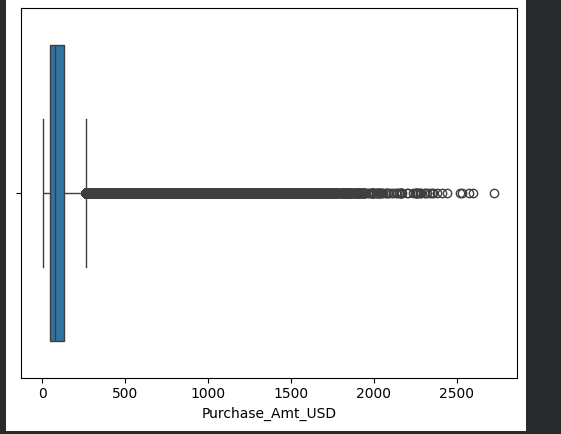

<Axes: xlabel='Purchase_Amt_USD'>

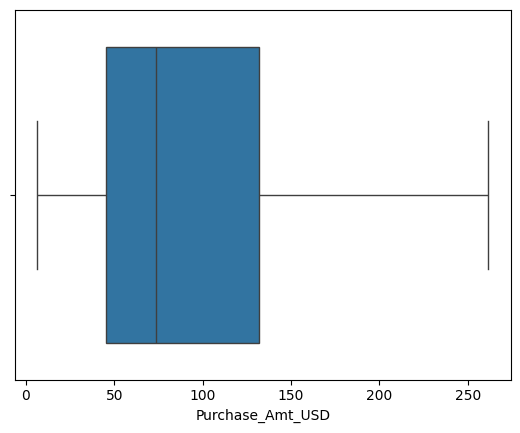

In [ ]:
import seaborn as sns
sns.boxplot(x=df_clean["Purchase_Amt_USD"])

Capping outliers


In [ ]:
# Function to cap outliers using IQR

def cap_outliers(series):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    return series.clip(lower_limit, upper_limit)

df_clean["Purchase_Amt_USD"] = cap_outliers(df_clean["Purchase_Amt_USD"])

df_clean["Annual_Income_USD"] = cap_outliers(df_clean["Annual_Income_USD"])

df_clean["Financial_Discipline_Index"] = cap_outliers(df_clean["Financial_Discipline_Index"])

In [ ]:
df_clean.head()

,Customer_ID,Age,Gender,Annual_Income_USD,Education_Level,Region,Loyalty_Status,Health_Status,Tech_Ecosystem_Lock,Financial_Discipline_Index,...,Product_Category,Sub_Category,Promotional_Usage,Purchase_Amt_USD,city_tier,year,month,week,dayofweek,season
0,1,56,Other,68627.79,High School,East,Regular,Fair,0,49.0,...,Food,Standard_Groceries,0,90.12,Tier3,2025,4,15,3,Spring
1,1,56,Other,68627.79,High School,East,Regular,Fair,0,49.0,...,Electronics,Impulse_Gadget,0,175.13,Tier3,2025,7,30,0,Summer
2,1,56,Other,68627.79,High School,East,Regular,Fair,0,49.0,...,Healthcare,Routine_Checkup,0,113.99,Tier3,2025,8,33,0,Summer
3,1,56,Other,68627.79,High School,East,Regular,Fair,0,49.0,...,Clothing,Trend_Impulse,0,65.49,Tier3,2025,11,45,1,Autumn
4,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47.0,...,Electronics,Replacement,0,75.38,Tier1,2025,1,2,1,Winter


In [41]:
df_clean.to_csv("clean_customer_spend_data.csv", index=False)

In [43]:
df_clean.head()

,Customer_ID,Age,Gender,Annual_Income_USD,Education_Level,Region,Loyalty_Status,Health_Status,Tech_Ecosystem_Lock,Financial_Discipline_Index,...,Product_Category,Sub_Category,Promotional_Usage,Purchase_Amt_USD,city_tier,year,month,week,dayofweek,season
0,1,56,Other,68627.79,High School,East,Regular,Fair,0,49.0,...,Food,Standard_Groceries,0,90.12,Tier3,2025,4,15,3,Spring
1,1,56,Other,68627.79,High School,East,Regular,Fair,0,49.0,...,Electronics,Impulse_Gadget,0,175.13,Tier3,2025,7,30,0,Summer
2,1,56,Other,68627.79,High School,East,Regular,Fair,0,49.0,...,Healthcare,Routine_Checkup,0,113.99,Tier3,2025,8,33,0,Summer
3,1,56,Other,68627.79,High School,East,Regular,Fair,0,49.0,...,Clothing,Trend_Impulse,0,65.49,Tier3,2025,11,45,1,Autumn
4,2,69,Female,96185.27,Bachelors,West,Regular,Good,0,47.0,...,Electronics,Replacement,0,75.38,Tier1,2025,1,2,1,Winter


In [44]:
# create model-ready dataset without touching clean dataset

df_model_ready = df_clean.copy()

print("Shape:", df_model_ready.shape)

Shape: (296733, 21)


One hot encoding


In [45]:
categorical_columns = [
    "Gender",
    "Education_Level",
    "Region",
    "Loyalty_Status",
    "Health_Status",
    "Tech_Ecosystem_Lock",
    "Product_Category",
    "Sub_Category",
    "city_tier",
    "season"
]

df_model_ready = pd.get_dummies(
    df_model_ready,
    columns=categorical_columns
)

In [46]:
df_model_ready.head()

,Customer_ID,Age,Annual_Income_USD,Financial_Discipline_Index,Purchase_Date,Promotional_Usage,Purchase_Amt_USD,year,month,week,...,Sub_Category_Standard_Groceries,Sub_Category_Supplements_Fitness,Sub_Category_Trend_Impulse,city_tier_Tier1,city_tier_Tier2,city_tier_Tier3,season_Autumn,season_Spring,season_Summer,season_Winter
0,1,56,68627.79,49.0,2025-04-10,0,90.12,2025,4,15,...,True,False,False,False,False,True,False,True,False,False
1,1,56,68627.79,49.0,2025-07-21,0,175.13,2025,7,30,...,False,False,False,False,False,True,False,False,True,False
2,1,56,68627.79,49.0,2025-08-11,0,113.99,2025,8,33,...,False,False,False,False,False,True,False,False,True,False
3,1,56,68627.79,49.0,2025-11-04,0,65.49,2025,11,45,...,False,False,True,False,False,True,True,False,False,False
4,2,69,96185.27,47.0,2025-01-07,0,75.38,2025,1,2,...,False,False,False,True,False,False,False,False,False,True


In [47]:
df_model_ready = df_model_ready.astype('int')
df_model_ready.head()

,Customer_ID,Age,Annual_Income_USD,Financial_Discipline_Index,Purchase_Date,Promotional_Usage,Purchase_Amt_USD,year,month,week,...,Sub_Category_Standard_Groceries,Sub_Category_Supplements_Fitness,Sub_Category_Trend_Impulse,city_tier_Tier1,city_tier_Tier2,city_tier_Tier3,season_Autumn,season_Spring,season_Summer,season_Winter
0,1,56,68627,49,1744243200000000000,0,90,2025,4,15,...,1,0,0,0,0,1,0,1,0,0
1,1,56,68627,49,1753056000000000000,0,175,2025,7,30,...,0,0,0,0,0,1,0,0,1,0
2,1,56,68627,49,1754870400000000000,0,113,2025,8,33,...,0,0,0,0,0,1,0,0,1,0
3,1,56,68627,49,1762214400000000000,0,65,2025,11,45,...,0,0,1,0,0,1,1,0,0,0
4,2,69,96185,47,1736208000000000000,0,75,2025,1,2,...,0,0,0,1,0,0,0,0,0,1


Scaling

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_columns = [
    "Age",
    "Annual_Income_USD",
    "Purchase_Amt_USD",
    "Financial_Discipline_Index",
    "year",
    "month",
    "week",
    "dayofweek"
]

df_model_ready[numeric_columns] = scaler.fit_transform(
    df_model_ready[numeric_columns]
)

In [49]:
df_model_ready.head()

,Customer_ID,Age,Annual_Income_USD,Financial_Discipline_Index,Purchase_Date,Promotional_Usage,Purchase_Amt_USD,year,month,week,...,Sub_Category_Standard_Groceries,Sub_Category_Supplements_Fitness,Sub_Category_Trend_Impulse,city_tier_Tier1,city_tier_Tier2,city_tier_Tier3,season_Autumn,season_Spring,season_Summer,season_Winter
0,1,0.844961,0.117147,-0.248255,1744243200000000000,0,-0.116521,0.0,-0.733008,-0.769735,...,1,0,0,0,0,1,0,1,0,0
1,1,0.844961,0.117147,-0.248255,1753056000000000000,0,1.082176,0.0,0.140616,0.231774,...,0,0,0,0,0,1,0,0,1,0
2,1,0.844961,0.117147,-0.248255,1754870400000000000,0,0.207833,0.0,0.431824,0.432075,...,0,0,0,0,0,1,0,0,1,0
3,1,0.844961,0.117147,-0.248255,1762214400000000000,0,-0.469078,0.0,1.305448,1.233282,...,0,0,1,0,0,1,1,0,0,0
4,2,1.712167,1.280155,-0.381788,1736208000000000000,0,-0.328055,0.0,-1.606632,-1.637708,...,0,0,0,1,0,0,0,0,0,1


In [50]:
df_model_ready.describe()

,Customer_ID,Age,Annual_Income_USD,Financial_Discipline_Index,Purchase_Date,Promotional_Usage,Purchase_Amt_USD,year,month,week,...,Sub_Category_Standard_Groceries,Sub_Category_Supplements_Fitness,Sub_Category_Trend_Impulse,city_tier_Tier1,city_tier_Tier2,city_tier_Tier3,season_Autumn,season_Spring,season_Summer,season_Winter
count,296733.000000,2.967330e+05,2.967330e+05,2.967330e+05,2.967330e+05,296733.000000,2.967330e+05,296733.0,2.967330e+05,2.967330e+05,...,296733.000000,296733.000000,296733.000000,296733.000000,296733.000000,296733.000000,296733.000000,296733.000000,296733.000000,296733.000000
mean,7514.036976,-8.826320e-17,-6.494026e-17,-7.212392e-17,1.751386e+18,0.269347,-5.976803e-17,0.0,5.180614e-17,1.065875e-16,...,0.162850,0.104950,0.132651,0.303536,0.447166,0.249298,0.250474,0.250707,0.254980,0.243839
std,4339.766627,1.000002e+00,1.000002e+00,1.000002e+00,9.060049e+15,0.443621,1.000002e+00,0.0,1.000002e+00,1.000002e+00,...,0.369229,0.306489,0.339198,0.459785,0.497202,0.432607,0.433287,0.433421,0.435851,0.429397
min,1.000000,-1.689948e+00,-1.724009e+00,-2.852154e+00,1.735690e+18,0.000000,-1.301115e+00,0.0,-1.606632e+00,-1.704476e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3743.000000,-8.894503e-01,-7.255471e-01,-7.156215e-01,1.743552e+18,0.000000,-7.511246e-01,0.0,-7.330078e-01,-8.365018e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7476.000000,-2.224459e-02,-2.220507e-02,1.881161e-02,1.751414e+18,0.000000,-3.562598e-01,0.0,1.406161e-01,3.147206e-02,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,11281.000000,8.449612e-01,6.796177e-01,6.864781e-01,1.759190e+18,1.000000,4.616743e-01,0.0,7.230320e-01,8.326787e-01,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
max,15000.000000,1.712167e+00,2.787365e+00,2.756244e+00,1.767053e+18,1.000000,2.294975e+00,0.0,1.596656e+00,1.700653e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Step 3. EDA

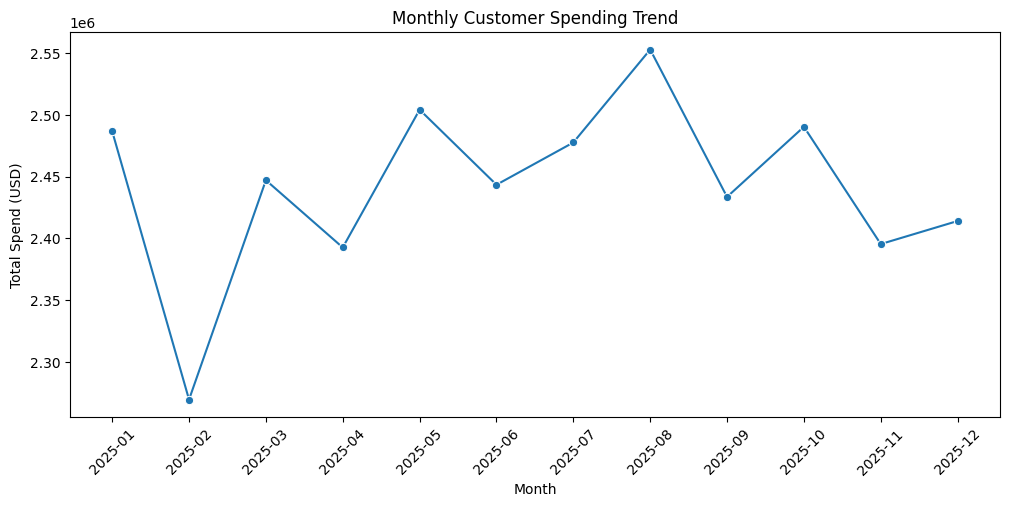

In [51]:
# total spending per month

monthly_spend = df_clean.groupby(
    ["year","month"]
)["Purchase_Amt_USD"].sum().reset_index()

# create month label
monthly_spend["year_month"] = (
    monthly_spend["year"].astype(str) + "-" +
    monthly_spend["month"].astype(str).str.zfill(2)
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_spend,
    x="year_month",
    y="Purchase_Amt_USD",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Customer Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spend (USD)")

plt.show()

Observation:
Customer spending varies across months, indicating temporal purchasing patterns.
Certain months show higher spending which may be influenced by promotions,
seasonality, or product demand.

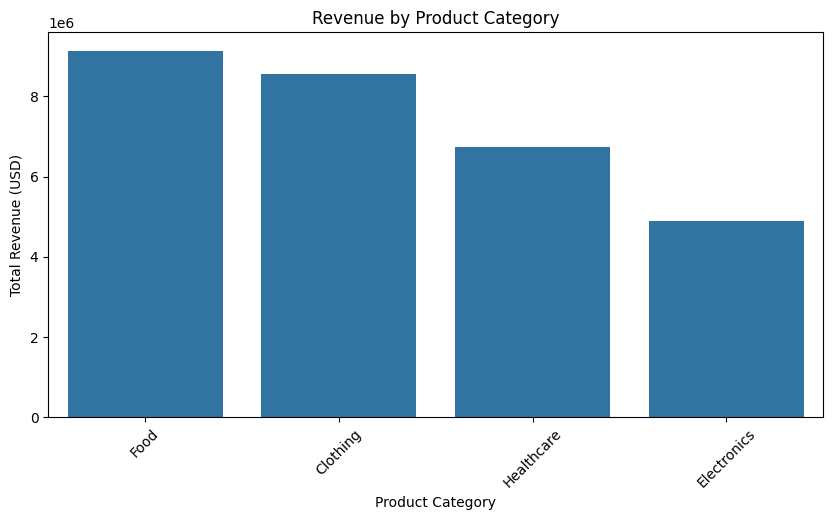

In [52]:
# total revenue by product category

category_revenue = df_clean.groupby(
    "Product_Category"
)["Purchase_Amt_USD"].sum().reset_index()

# sort values for better visualization
category_revenue = category_revenue.sort_values(
    by="Purchase_Amt_USD",
    ascending=False
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=category_revenue,
    x="Product_Category",
    y="Purchase_Amt_USD"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue (USD)")

plt.xticks(rotation=45)

plt.show()

Observation:
Certain product categories generate significantly higher revenue.
High-value categories such as electronics typically drive larger
transaction amounts, while everyday items may contribute through
frequent purchases.

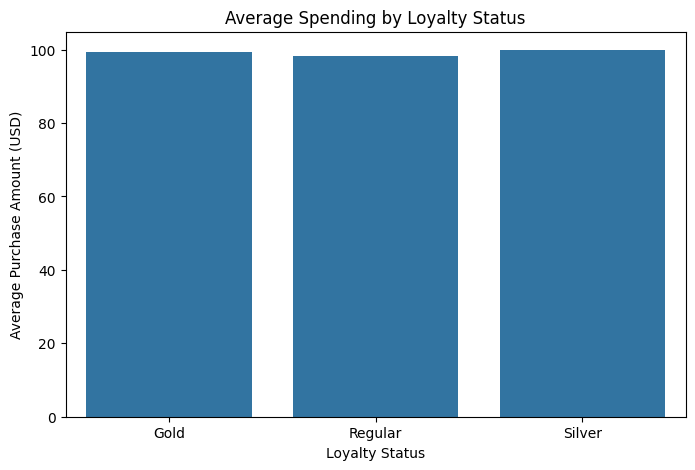

In [53]:
# average purchase amount by loyalty status

loyalty_spend = df_clean.groupby(
    "Loyalty_Status"
)["Purchase_Amt_USD"].mean().reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=loyalty_spend,
    x="Loyalty_Status",
    y="Purchase_Amt_USD"
)

plt.title("Average Spending by Loyalty Status")
plt.xlabel("Loyalty Status")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()

Observation:
Customers with higher loyalty status tend to spend more per transaction.
This suggests that loyalty programs influence purchasing behavior
and may be a strong predictor of future customer spending.

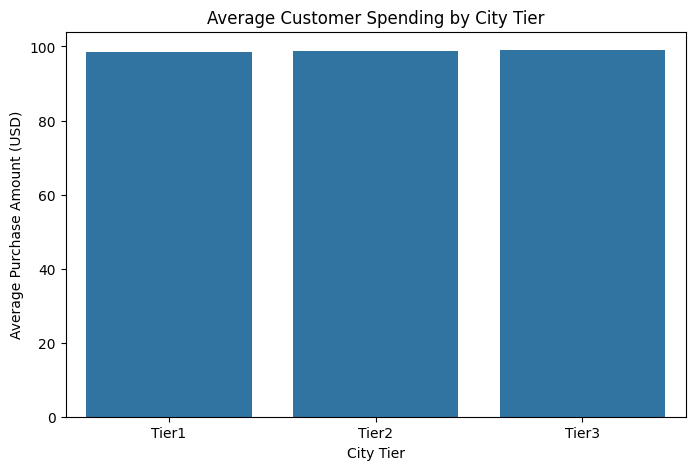

In [54]:
# average purchase amount by city tier

city_spend = df_clean.groupby(
    "city_tier"
)["Purchase_Amt_USD"].mean().reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=city_spend,
    x="city_tier",
    y="Purchase_Amt_USD"
)

plt.title("Average Customer Spending by City Tier")
plt.xlabel("City Tier")
plt.ylabel("Average Purchase Amount (USD)")

plt.show()

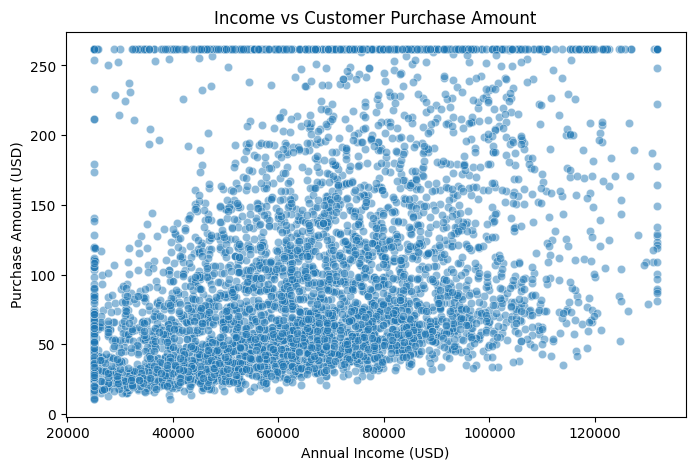

In [55]:
# take a sample for visualization
sample_df = df_clean.sample(5000, random_state=42)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=sample_df,
    x="Annual_Income_USD",
    y="Purchase_Amt_USD",
    alpha=0.5
)

plt.title("Income vs Customer Purchase Amount")
plt.xlabel("Annual Income (USD)")
plt.ylabel("Purchase Amount (USD)")

plt.show()

In [56]:
df_model_ready.head()

,Customer_ID,Age,Annual_Income_USD,Financial_Discipline_Index,Purchase_Date,Promotional_Usage,Purchase_Amt_USD,year,month,week,...,Sub_Category_Standard_Groceries,Sub_Category_Supplements_Fitness,Sub_Category_Trend_Impulse,city_tier_Tier1,city_tier_Tier2,city_tier_Tier3,season_Autumn,season_Spring,season_Summer,season_Winter
0,1,0.844961,0.117147,-0.248255,1744243200000000000,0,-0.116521,0.0,-0.733008,-0.769735,...,1,0,0,0,0,1,0,1,0,0
1,1,0.844961,0.117147,-0.248255,1753056000000000000,0,1.082176,0.0,0.140616,0.231774,...,0,0,0,0,0,1,0,0,1,0
2,1,0.844961,0.117147,-0.248255,1754870400000000000,0,0.207833,0.0,0.431824,0.432075,...,0,0,0,0,0,1,0,0,1,0
3,1,0.844961,0.117147,-0.248255,1762214400000000000,0,-0.469078,0.0,1.305448,1.233282,...,0,0,1,0,0,1,1,0,0,0
4,2,1.712167,1.280155,-0.381788,1736208000000000000,0,-0.328055,0.0,-1.606632,-1.637708,...,0,0,0,1,0,0,0,0,0,1


Linear Regression
RMSE: 1.634500643016612
MAE: 1.2151763313606683
R2: 0.26841703437285624
-------------------
Random Forest
RMSE: 1.6253915065335691
MAE: 1.2122048201561362
R2: 0.27654859369092477
-------------------


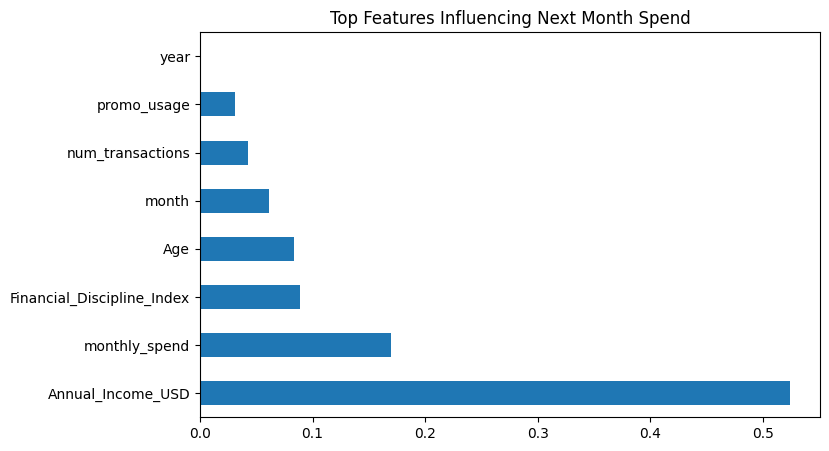

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------
# 1. Create Customer-Month Dataset
# -------------------------------

customer_month = df_model_ready.groupby(
    ["Customer_ID", "year", "month"]
).agg(
    monthly_spend=("Purchase_Amt_USD", "sum"),
    num_transactions=("Purchase_Amt_USD", "count"),
    promo_usage=("Promotional_Usage", "sum")
).reset_index()


# -------------------------------
# 2. Merge Customer Attributes
# -------------------------------

customer_info = df_model_ready.drop_duplicates("Customer_ID")[[
    "Customer_ID",
    "Age",
    "Annual_Income_USD",
    "Financial_Discipline_Index"
]]

customer_month = customer_month.merge(
    customer_info,
    on="Customer_ID",
    how="left"
)


# -------------------------------
# 3. Create Prediction Target
# -------------------------------

customer_month = customer_month.sort_values(
    ["Customer_ID", "year", "month"]
)

customer_month["next_month_spend"] = (
    customer_month.groupby("Customer_ID")["monthly_spend"]
    .shift(-1)
)

customer_month = customer_month.dropna()


# -------------------------------
# 4. Feature Matrix
# -------------------------------

X = customer_month.drop(
    ["Customer_ID", "next_month_spend"],
    axis=1
)

y = customer_month["next_month_spend"]


# -------------------------------
# 5. Train Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# -------------------------------
# 6. Train Linear Regression
# -------------------------------

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)


# -------------------------------
# 7. Train Random Forest
# -------------------------------

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


# -------------------------------
# 8. Evaluation Function
# -------------------------------

def evaluate(y_true, y_pred, model_name):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("-------------------")


evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")


# -------------------------------
# 9. Feature Importance
# -------------------------------

import matplotlib.pyplot as plt

importances = rf_model.feature_importances_

features = X.columns

fi = pd.Series(importances, index=features)

fi = fi.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

fi.plot(kind="barh")

plt.title("Top Features Influencing Next Month Spend")

plt.show()

In [58]:
customer_month = df_model_ready.groupby(
    ["Customer_ID", "year", "month"]
).agg(
    monthly_spend=("Purchase_Amt_USD", "sum"),
    num_transactions=("Purchase_Amt_USD", "count"),
    promo_usage=("Promotional_Usage", "sum")
).reset_index()

In [59]:
customer_info = df_model_ready.drop_duplicates("Customer_ID")[[
    "Customer_ID",
    "Age",
    "Annual_Income_USD",
    "Financial_Discipline_Index"
]]

customer_month = customer_month.merge(customer_info, on="Customer_ID")

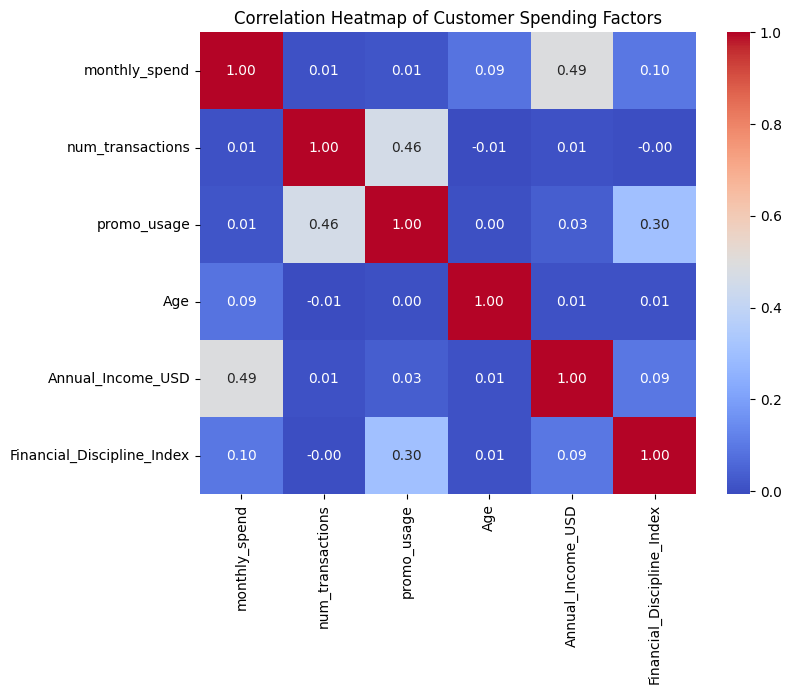

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_features = customer_month[[
    "monthly_spend",
    "num_transactions",
    "promo_usage",
    "Age",
    "Annual_Income_USD",
    "Financial_Discipline_Index"
]]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_features.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Customer Spending Factors")

plt.show()

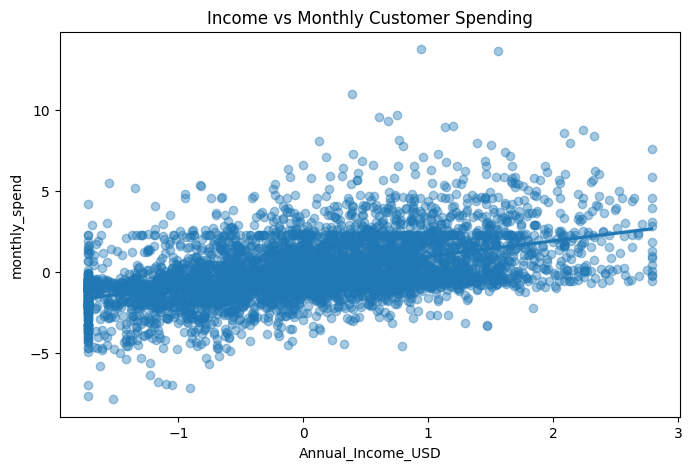

In [61]:
sample = customer_month.sample(5000, random_state=42)

plt.figure(figsize=(8,5))

sns.regplot(
    data=sample,
    x="Annual_Income_USD",
    y="monthly_spend",
    scatter_kws={"alpha":0.4}
)

plt.title("Income vs Monthly Customer Spending")

plt.show()

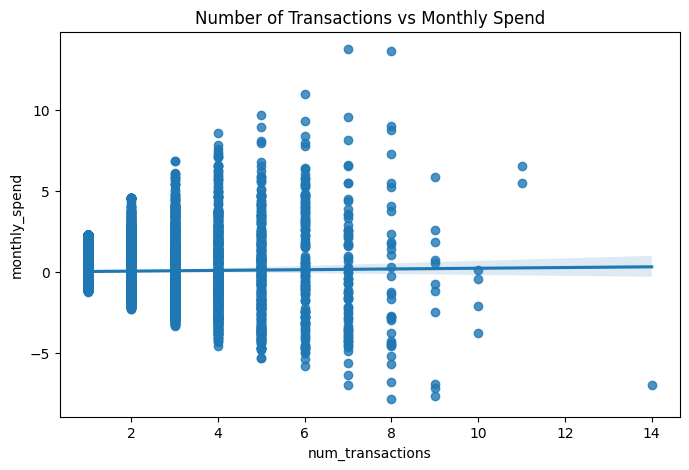

In [62]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=sample,
    x="num_transactions",
    y="monthly_spend"
)

plt.title("Number of Transactions vs Monthly Spend")

plt.show()

In [64]:
customer_month["next_month_spend"] = (
    customer_month.groupby("Customer_ID")["monthly_spend"]
    .shift(-1)
)

In [66]:
customer_month = customer_month.dropna()

In [67]:
customer_month.head()

,Customer_ID,year,month,monthly_spend,num_transactions,promo_usage,Age,Annual_Income_USD,Financial_Discipline_Index,next_month_spend
0,1,0.0,-0.733008,-0.116521,1,0,0.844961,0.117147,-0.248255,1.082176
1,1,0.0,0.140616,1.082176,1,0,0.844961,0.117147,-0.248255,0.207833
2,1,0.0,0.431824,0.207833,1,0,0.844961,0.117147,-0.248255,-0.469078
4,2,0.0,-1.606632,-0.233747,6,1,1.712167,1.280155,-0.381788,-0.737728
5,2,0.0,-1.315424,-0.737728,5,0,1.712167,1.280155,-0.381788,1.973618


In [68]:
features = [
    "monthly_spend",
    "num_transactions",
    "promo_usage",
    "month"
]

X = customer_month[features]

y = customer_month["next_month_spend"]

In [72]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------
# 1. Create Feature Dataset
# ---------------------------

features = [
    "monthly_spend",
    "num_transactions",
    "promo_usage",
    "Age",
    "Annual_Income_USD",
    "Financial_Discipline_Index",
    "month"
]

X = customer_month[features]

y = customer_month["next_month_spend"]


# ---------------------------
# 2. Train Test Split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ---------------------------
# 3. Train Linear Regression
# ---------------------------

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)


# ---------------------------
# 4. Train Random Forest
# ---------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)


# ---------------------------
# 5. Evaluation Function
# ---------------------------

def evaluate_model(y_true, y_pred, model_name):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("Model:", model_name)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2 Score :", r2)
    print("--------------------------------")


# ---------------------------
# 6. Evaluate Models
# ---------------------------

evaluate_model(y_test, lr_predictions, "Linear Regression")

evaluate_model(y_test, rf_predictions, "Random Forest")

Model: Linear Regression
RMSE: 1.634500643016612
MAE: 1.2151763313606683
R2 Score : 0.26841703437285624
--------------------------------
Model: Random Forest
RMSE: 1.625278404809823
MAE: 1.2120606597331547
R2 Score : 0.27664927190162336
--------------------------------


In [71]:
import joblib
from google.colab import files

# 1. Save the Random Forest Model
joblib.dump(rf_model, 'rf_spend_model.pkl')

# 2. Save the Scaler (This is the most important part!)
joblib.dump(scaler, 'data_scaler.pkl')

# 3. Save the exact feature names
features = ["monthly_spend", "num_transactions", "promo_usage", "Age", "Annual_Income_USD", "Financial_Discipline_Index", "month"]
joblib.dump(features, 'feature_names.pkl')

# 4. Download all three
files.download('rf_spend_model.pkl')
files.download('data_scaler.pkl')
files.download('feature_names.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>